In [1]:
%run ~/analysisLibraries

In [2]:
%matplotlib inline

In [3]:
%load_ext rpy2.ipython

## Read data containing all necessary scores and relevant genes calculated in the previous notebook

In [4]:
adata = sc.read('./write/SDA_object_100comps.h5ad')

component can be changed using the software papermill to execute notebooks in the workflow

In [5]:
comp=0

In [6]:
# Parameters
comp = 14


## Open SDA matrices

In [7]:
A = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/A', sep=' ', header=None)
#B is only for multi-tissues tensor
#B = pd.read_csv('SDA/CELLS_sctransform_onematrix_data/it2000/B1', sep=' ', header=None)
X = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/X1', sep=' ', header=None)

$A$ contains the score of each cell in the components. This score can be used as a "soft clustering" once it is normalized. We will try to do that in the notebook that follows this one. 

In [8]:
A.shape

(10548, 100)

In [9]:
A.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.237044,-0.444741,-0.521709,-0.421176,-0.191632,-0.039443,-0.011519,0.313026,-0.017442,-0.014353,...,-0.713952,0.084345,0.325848,0.577062,-0.704971,-0.307896,0.102466,-0.919935,-0.196817,-1.101270
1,0.411126,-0.113899,-0.404359,-0.412903,0.112982,-0.168036,-0.364643,0.746365,-0.003497,-0.242012,...,0.923655,-0.432896,0.018581,-0.329805,-0.004898,-0.298961,0.290554,0.328762,-0.211422,0.605521
2,-0.554124,-2.115210,0.572701,-0.509780,0.577237,-0.234850,0.450509,0.208679,0.177719,-0.164977,...,-0.382789,0.511820,0.686443,0.116738,-0.315359,-0.109686,1.740900,-0.937221,0.846761,0.562644
3,-0.258430,1.402740,1.303190,-0.759115,1.298820,-0.058847,-0.725280,-0.359907,0.306425,1.195000,...,-0.727815,0.416148,2.020470,-0.108066,-0.465147,-1.716540,0.712520,-0.855888,0.907461,0.266163
4,-0.338097,1.336100,-1.538940,0.907896,0.817900,1.415150,-0.130066,-0.545487,-0.755909,-0.912024,...,-1.259190,-0.325736,0.157799,1.454890,-0.115039,-0.391225,1.149520,0.961979,-0.198099,0.624347


In [10]:
#B

$X$ contains the loading of each gene in each component according to the spike-and-slab prior. The sign of the loading has to be considered together with the sign of the cell score to see if the resulting sign is positive (significant expression of gene) or negative (significant underexpression of gene)

In [11]:
X.columns = adata[:,(np.log(adata.var['variance-Cells'])>0)|(np.log(adata.var['variance-Nuclei']>-1))].var_names

In [12]:
X.shape

(100, 6276)

In [13]:
X.head()

,AURKAIP1,MRPL20,SSU72,LOC469457,GNB1,MORN1,RER1,MMEL1,ACTRT2,CCDC27,...,amplicon-chrX-FAM9A/B/C-6,amplicon-chrX-GAGE10-0,amplicon-chrX-LOC107966365-0,amplicon-chrX-LOC112206844-0,amplicon-chrX-LOC112206844-2,amplicon-chrX-LOC112206844-4,amplicon-chrX-LOC465705-2,amplicon-chrX-PAGE5-3,amplicon-chrX-SPANXN5-2,amplicon-chrX-SSX1/3/2B-15
0,-0.251518,-0.050381,-0.000772,-0.082587,-0.000094,-0.001789,-0.132522,0.000048,-0.053861,-0.035661,...,0.000333,0.000363,-0.000149,-0.036358,-0.000366,0.002521,-0.061503,0.000056,0.000141,0.006134
1,0.000395,0.000193,-0.000607,0.001750,0.000787,-0.001956,-0.000217,-0.000121,0.000535,-0.000017,...,0.066423,-0.000271,0.000069,0.029602,0.001012,0.000030,-0.000178,0.000639,-0.026457,0.000855
2,-0.000250,-0.000108,-0.000195,0.030246,0.000202,-0.001048,-0.000112,0.000151,-0.001854,-0.000145,...,-0.000141,0.001418,-0.000997,-0.000141,-0.039148,-0.000122,0.000968,-0.000012,-0.001109,0.000334
3,0.000423,-0.000399,-0.000322,0.002582,0.000288,0.000177,-0.000765,0.046786,0.000218,0.000263,...,-0.000404,0.000993,0.000137,0.000224,0.043691,-0.000044,0.000219,0.000187,0.000062,-0.000340
4,-0.000056,-0.000013,0.000059,-0.000223,0.033124,-0.000006,0.000276,-0.107145,0.000001,-0.051293,...,-0.034791,0.000032,0.061013,-0.000074,-0.000050,0.000003,0.000006,0.000007,-0.000034,-0.037562


## Some plots and measures about the specific components

#### UMAP of cell scores and batches

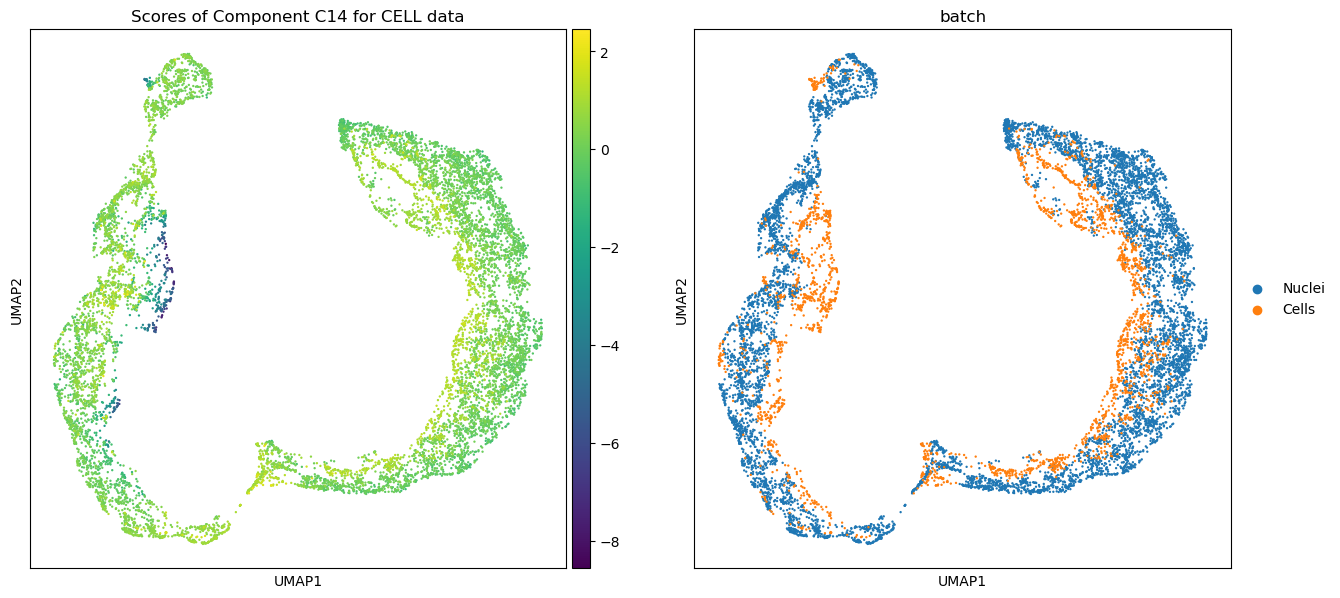

In [14]:
plt.rcParams['figure.figsize']=(7,7)
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}','batch'],
          title=f'Scores of Component C{comp} for CELL data')

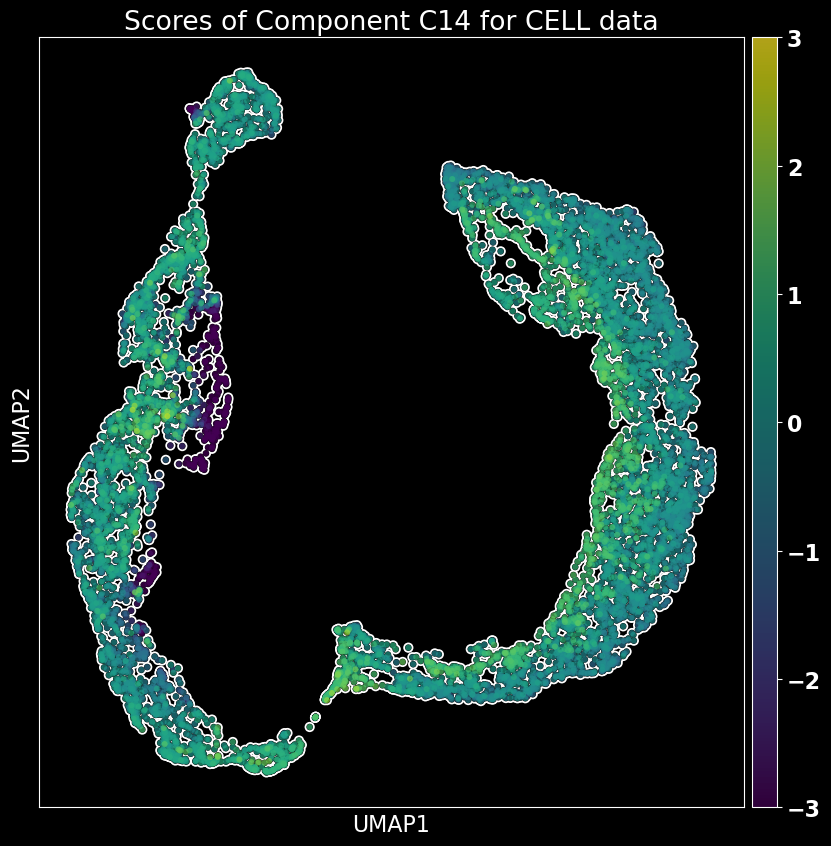

In [15]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True, outline_color=['white','black'],
          save=f'scores_C{comp}_dark.png', )

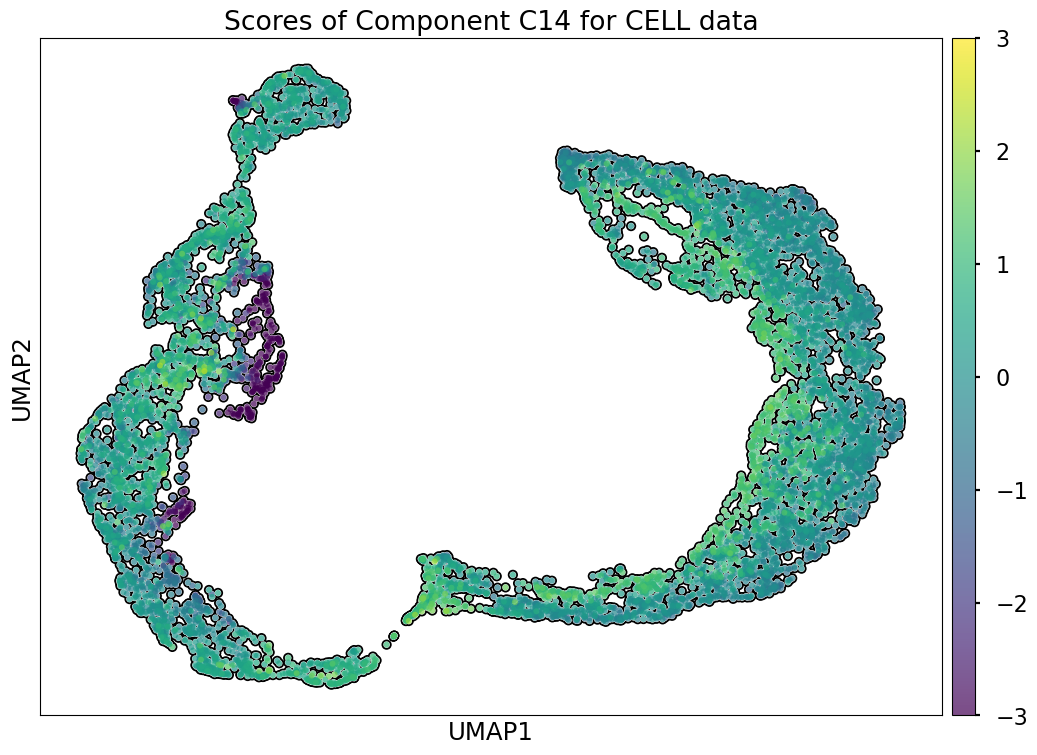

In [16]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True,
          save=f'scores_C{comp}_white.png', )

In [17]:
try:
    IRRELEVANT=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['IRRELEVANT']
except Exception as e:
    IRRELEVANT=0
try:
    POSITIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['POSITIVE']
except Exception as e:
    POSITIVE=0
try:
    NEGATIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['NEGATIVE']
except Exception as e:
     NEGATIVE=0

In [18]:
onlyrelevant = np.array( adata.obs[f'sda_cell_relevant_C{comp}'].copy() )
onlyrelevant[onlyrelevant=='IRRELEVANT']=None
adata.obs[f'sda_cell_relevantonly_C{comp}'] = onlyrelevant

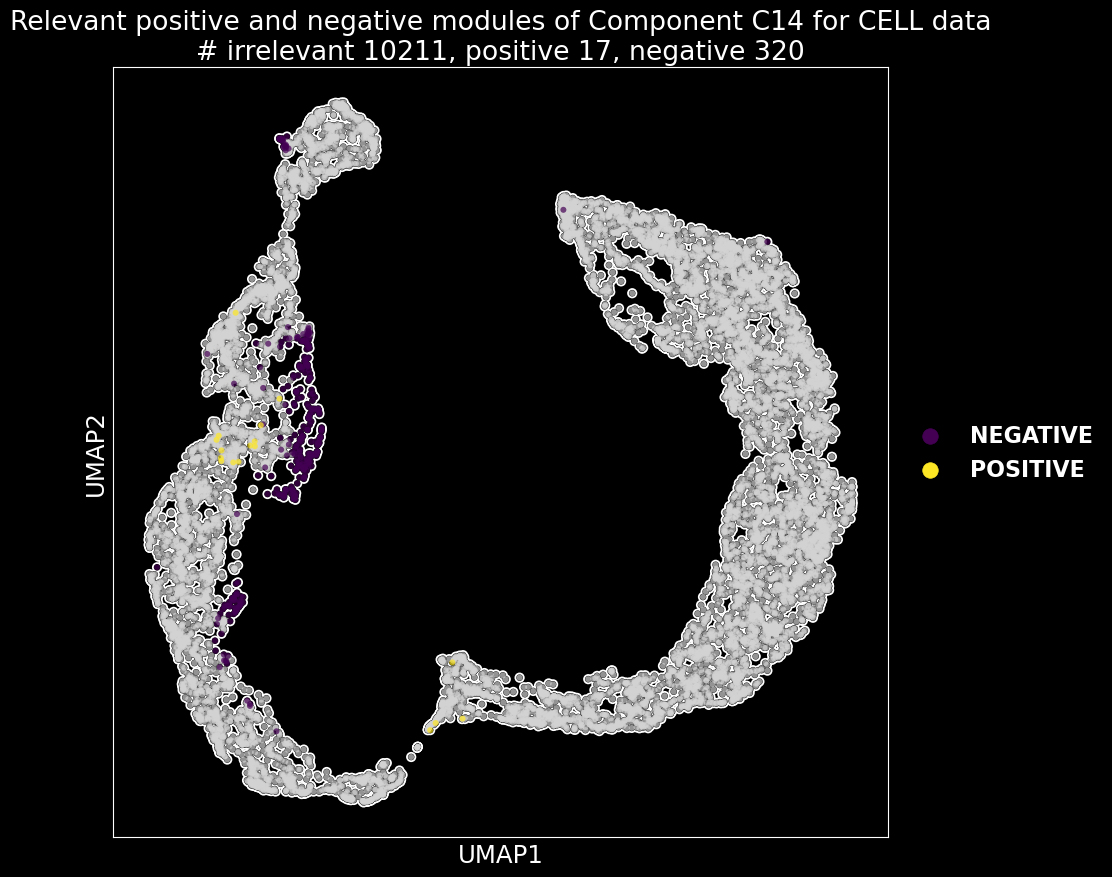

In [19]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data\n# irrelevant {IRRELEVANT}, positive {POSITIVE}, negative {NEGATIVE}', 
          size=75, add_outline=True, outline_color=['white','black'], palette='viridis',
          save=f'relevance_C{comp}_dark.png')

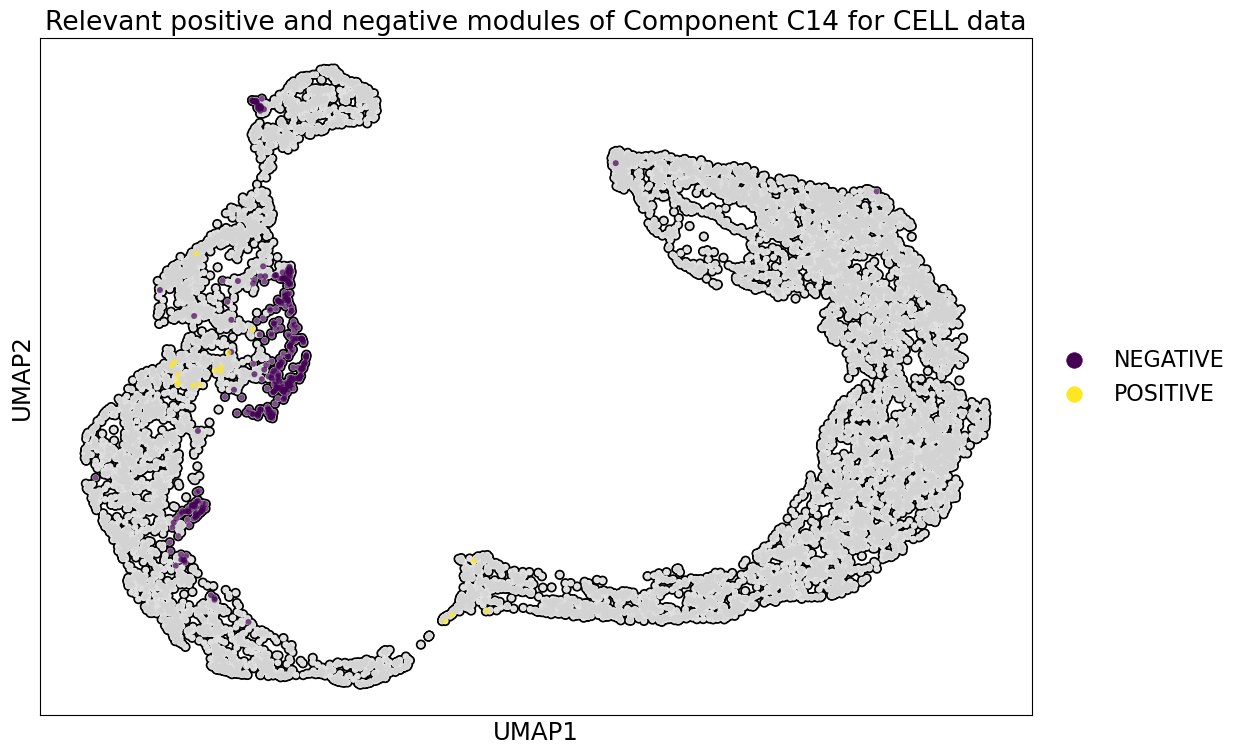

In [20]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data', palette='viridis',
          size=75, add_outline=True,
          save=f'relevance_C{comp}_white.png')

### mean and std of positive and negative cell scores for each batch

In [21]:
score_cells = adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}']
score_nuclei = adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}']

In [22]:
print( 'Positive scores nuclei - mean:', np.mean(score_nuclei[score_nuclei>1.5]), 'var:', np.std(score_nuclei[score_nuclei>1.5])  )
print( 'Positive scores cells  - mean:', np.mean(score_cells[score_cells>2]), 'var:', np.std(score_cells[score_cells>2])  )

Positive scores nuclei - mean: 1.7237300000000002 var: 0.2183727476455927
Positive scores cells  - mean: 2.1557209999999998 var: 0.15512479894910425


In [23]:
print( 'Negative scores nuclei - mean:', np.mean(score_nuclei[score_nuclei<-1.5]), 'var:', np.std(score_nuclei[score_nuclei<-1.5])  )
print( 'Negative scores cells  - mean:', np.mean(score_cells[score_cells<-2]), 'var:', np.std(score_cells[score_cells<-2])  )

Negative scores nuclei - mean: -1.778751111111111 var: 0.34648593258102595
Negative scores cells  - mean: -4.306566752411575 var: 1.5468236903185222


### T-test to detect batch differences in a module

We check if positive/negative scores are specific for either cells or genes, so we can highlight that in our information output

In [24]:
import scipy

Two-sided test of positive scores of cells vs nuclei

In [25]:
scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])

Ttest_indResult(statistic=69.28995142768657, pvalue=0.0)

Two-sided test of negative scores of cells vs nuclei

In [26]:
scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

Ttest_indResult(statistic=-66.65831135364456, pvalue=0.0)

Cells have more transcripts than nuclei and this is reflected in a bit higher/lower score in general, so we choose a strict threshold to avoid detecting batch differences where they are mostly due to technical causes

In [27]:
pos_stat, pos_p = scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])
neg_stat, neg_p = scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

batch_effect_pos='No'
batch_effect_neg='No'

if np.abs(pos_stat) > 10:
    batch_effect_pos='Yes'
print(f'Positive module batch differences: {batch_effect_pos}')
    
if np.abs(neg_stat) > 10:
    batch_effect_neg='Yes'
print(f'Negative module batch differences: {batch_effect_neg}')

Positive module batch differences: Yes
Negative module batch differences: Yes


<Axes: xlabel='SDA_cellscore_C14', ylabel='Count'>

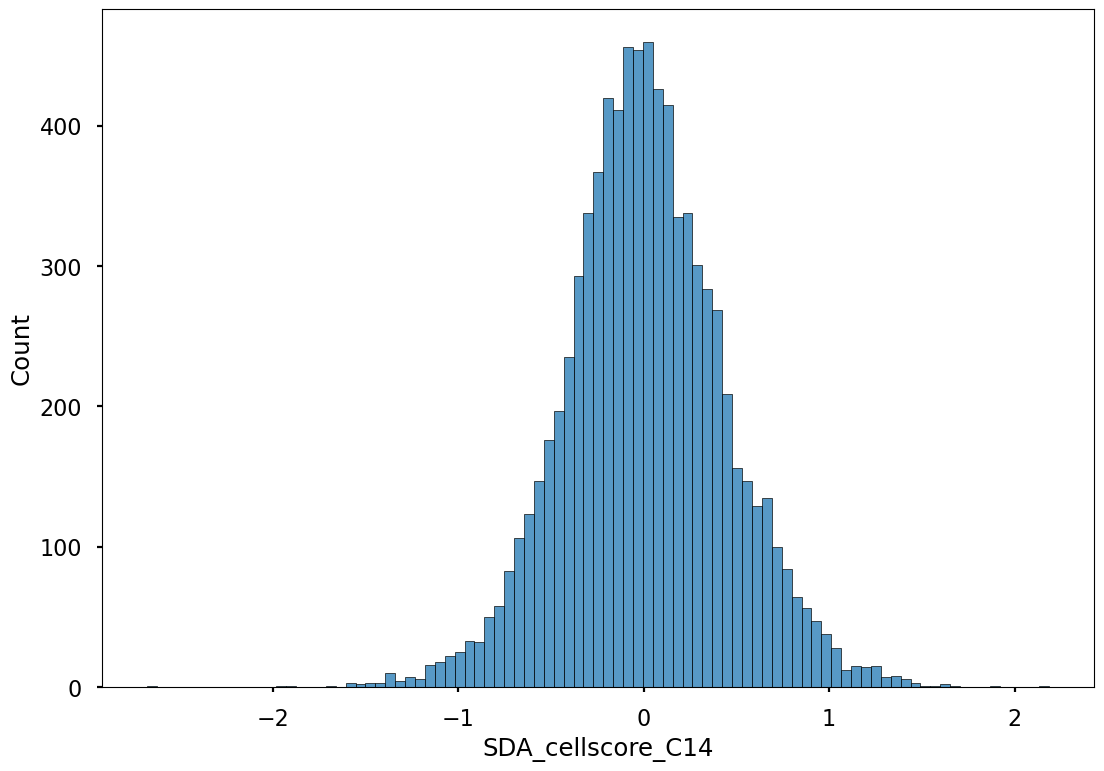

In [28]:
plt.rcParams['figure.figsize']=(6,6)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.histplot(adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}'])

<Axes: xlabel='SDA_cellscore_C14', ylabel='Count'>

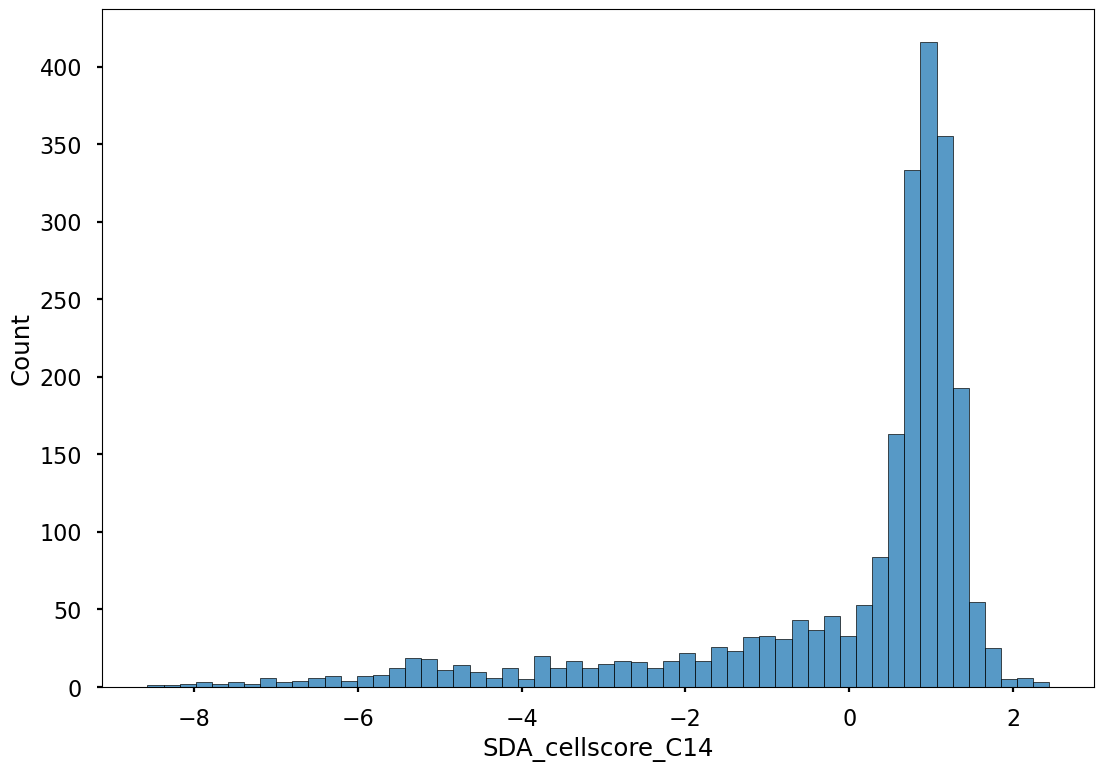

In [29]:
sns.histplot(adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'])

Genes significant for components (whole list printed to easy copy-pase for onlyne databases):

In [30]:
print(f'Genes significant for positive C{comp}:', adata[:,adata.var[f'sda_pos_C{comp}']].shape[1])

Genes significant for positive C14: 926


In [31]:
for i in adata[:,adata.var[f'sda_pos_C{comp}']].var_names:
    print(i)

NPHP4
CAMTA1
RERE
SLC2A5
VPS13D
PLEKHM2
SPEN
PINK1
ATP5IF1
EPB41
PHC2
HMGB4
TEKT2
OSCP1
MRPS15
DNALI1
MACF1
SCMH1
FOXJ3
YBX1
CDC20
ST3GAL3
ERI3
ZSWIM5
FAAH
SPATA6
AGBL4
FAF1
LOC107966681
ZFYVE9
LOC107966751
GLIS1
LOC742772
FGGY
NEGR1
SH3GLB1
HS2ST1
HFM1
BRDT
DPYD
C1H1orf194
KIAA1324
GSTM3
PIFO
RAP1A
DDX20
LOC107968074
LOC112204994
SYCP1
PHGDH
LOC112208396
LOC738370
PLEKHO1
C1H1orf56
SMCP
LELP1
NUP210L
ASH1L
GON4L
ARHGEF2
TSACC
CFAP45
KLHDC9
LOC107969123
ILDR2
C1H1orf105
LOC112204100
RABGAP1L
RASAL2
CEP350
ACBD6
XPR1
SHCBP1L
SWT1
IPO9
PPP1R12B
SRGAP2
DYRK3
LOC745816
SLC30A1
NEK2
CENPF
TRIM17
LOC112206648
SLC35F3
RBM34
AKT3
SMYD3
SCCPDH
AHCTF1
LOC107970852
SH3YL1
ALKAL2
MYT1L
TRAPPC12
LOC100615276
NBAS
VSNL1
PUM2
PFN4
FAM228A
AGBL5
ABHD1
BIRC6
LTBP1
CDC42EP3
EML4
THADA
SRBD1
GTF2A1L
PSME4
RTN4
CFAP36
LOC104004979
VPS54
APLF
AAK1
LOC107973512
EXOC6B
RAB11FIP5
ALMS1
C2AH2orf81
CTNNA2
TCF7L1
TEKT4
NPHP1
SH3RF3
LOC107971394
LOC107973562
LOC741694
TMEM131
TSGA10
AFF3
DBI
CLASP1
LOC107973756
S

In [32]:
print(f'Genes significant for negative C{comp}:', adata[:,adata.var[f'sda_neg_C{comp}']].shape[1])

Genes significant for negative C14: 1714


In [33]:
for i in adata[:,adata.var[f'sda_neg_C{comp}']].var_names:
    print(i)

MRPL20
SSU72
RER1
RPL22
PER3
PARK7
ENO1
SLC25A33
LZIC
SDF4
PRDM2
ACTL8
MINOS1
OTUD3
DDOST
HP1BP3
CDC42
KDM1A
HNRNPR
RPL11
PITHD1
SRSF10
SRRM1
CLIC4
SYF2
RSRP1
STMN1
CEP85
NUDC
WASF2
FAM76A
RPA2
DNAJC8
PHACTR4
TAF12
YTHDF2
SRSF4
ZCCHC17
PTP4A2
KHDRBS1
TXLNA
HDAC1
ZBTB8OS
RBBP4
S100PBP
RNF19B
SFPQ
PSMB2
TRAPPC3
THRAP3
MEAF6
CDCA8
SF3A3
MYCBP
AKIRIN1
NDUFS5
PABPC4
CAP1
SVBP
EBNA1BP2
ATP6V0B
RPS8
PRDX1
NASP
GPBP1L1
IPP
LRRC41
LOC742376
ATPAF1
RPL35A
SCP2
LOC107966756
DMRTB1
HSPB11
TMEM59
TM2D1
USP1
JAK1
MIER1
SERBP1
DEPDC1
SRSF11
LRRIQ3
ACADM
PIGK
USP33
GNG5
SPATA1
ZNHIT6
ZNF326
RPL5
MTF2
DNTTIP2
ARHGAP29
PTBP2
SASS6
PRPF38B
WDR47
GSTM4
LAMTOR5
LRIF1
ATP5PB
CAPZA1
SLC16A1
RSBN1
HIPK1
LOC107967746
LOC104002001
RNF115
RBM8A
MRPS21
HORMAD1
PIP5K1A
TCHH
ILF2
RPS27
TPM3
UBAP2L
UBE2Q1
MTX1
SSR2
CCT3
COPA
PFDN2
SDHC
UAP1
NUF2
TMCO1
MAEL
TIPRL
KIFAP3
MROH9
PRRC2C
RC3H1
CACYBP
TOR1AIP1
DHX9
LAMC1
ARPC5
TPR
TROVE2
KCNT2
UBE2T
ATP2B4
ZC3H11A
SNRPE
NUCKS1
CD46
RRP15
EPRS
SRP9
ACBD3
PARP1
ARF1
RAB4A
SP

#### Cells scores by cluster

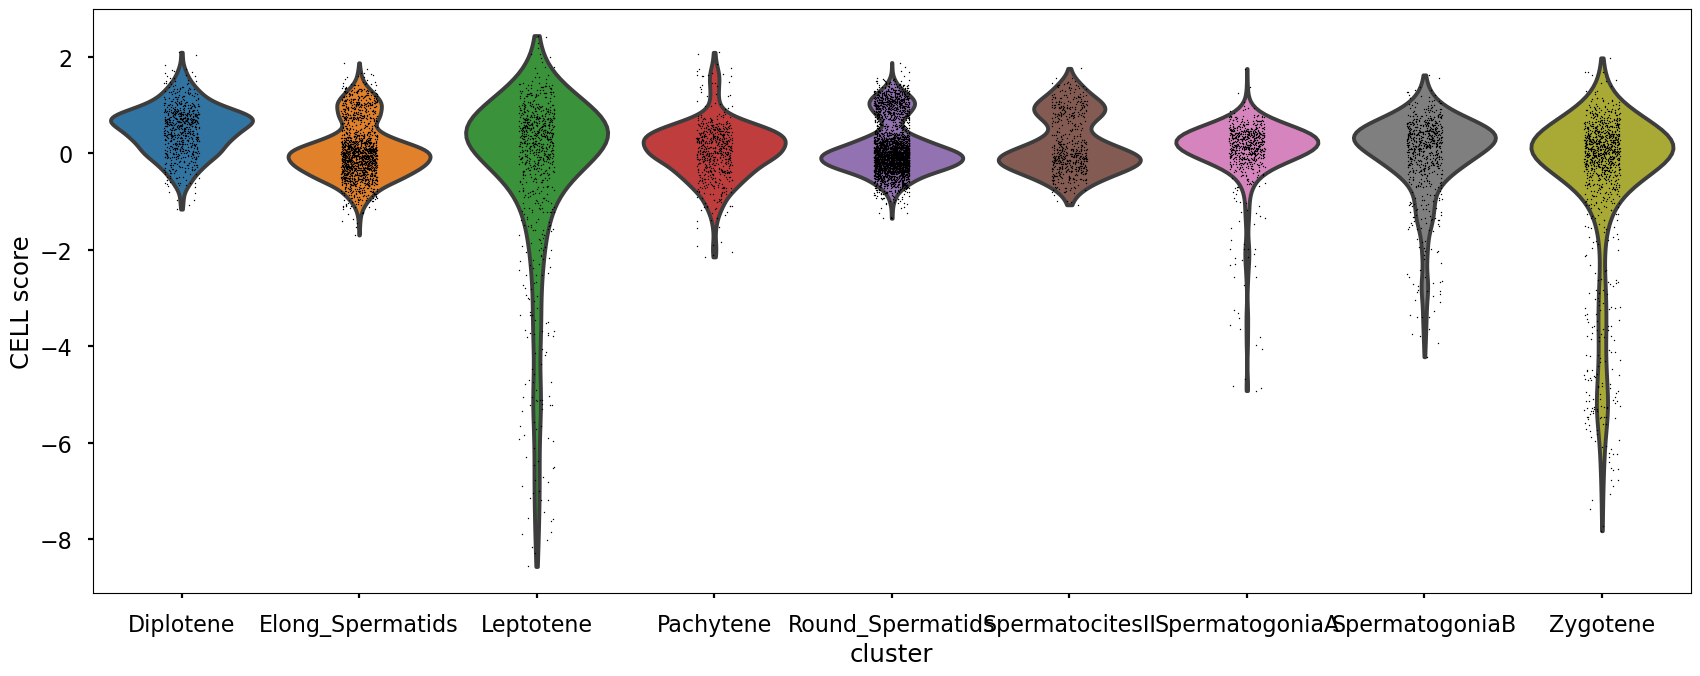

In [34]:
plt.rcParams['figure.figsize']=(16,8)
sc.pl.violin(adata, 
             groupby='spermatogenesis', keys=f'SDA_cellscore_C{comp}',
             title=f'CELLS score for SDA component C{comp}',
             xlabel='cluster', ylabel='CELL score')

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'SpermatogoniaA'),
  Text(1, 0, 'SpermatogoniaB'),
  Text(2, 0, 'Leptotene'),
  Text(3, 0, 'Zygotene'),
  Text(4, 0, 'Pachytene'),
  Text(5, 0, 'Diplotene'),
  Text(6, 0, 'SpermatocitesII'),
  Text(7, 0, 'Round_Spermatids'),
  Text(8, 0, 'Elong_Spermatids')])

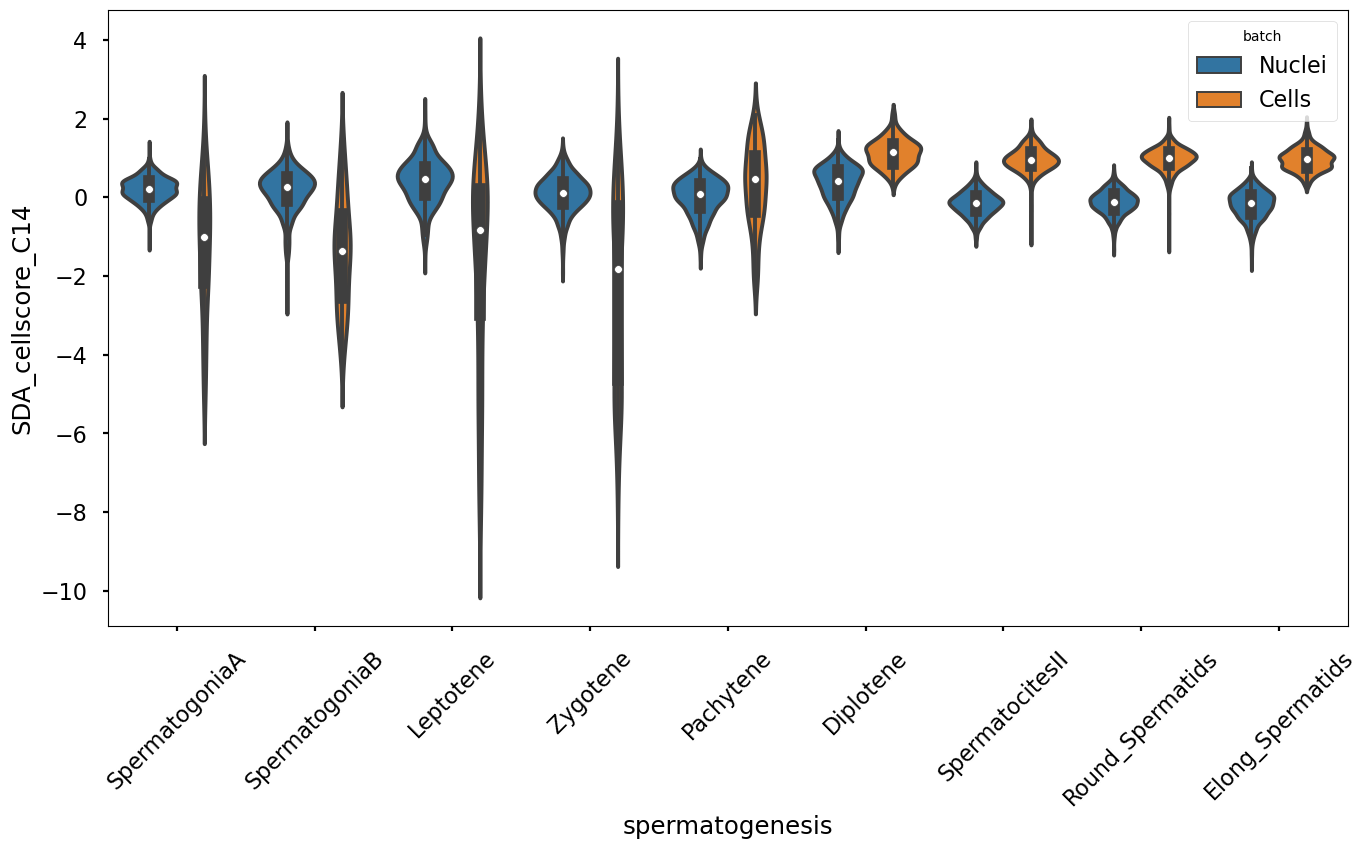

In [35]:
plt.rcParams['figure.figsize']=(16,8)
sns.violinplot(x='spermatogenesis', y=f'SDA_cellscore_C{comp}', hue='batch', data=adata.obs, 
               order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids'])
plt.xticks(rotation=45)

#### Cell scores by pseudotimes and relative threshold lines

In [36]:
score_neg = -2 #min( -2, np.quantile(A[int(comp)], .1) )
score_pos = 2 #max( +2, np.quantile(A[int(comp)], .9) )

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C14')

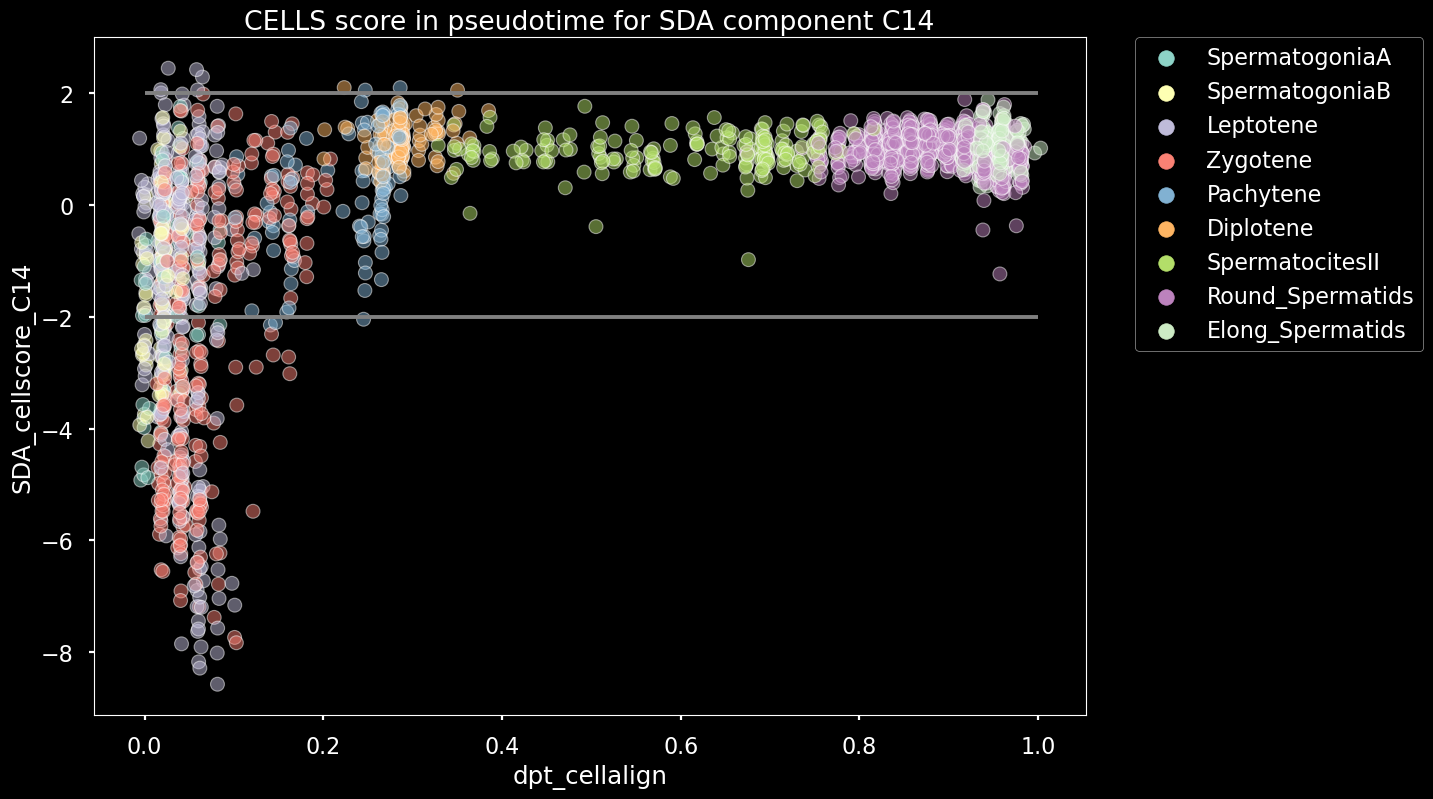

In [37]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.5, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C14')

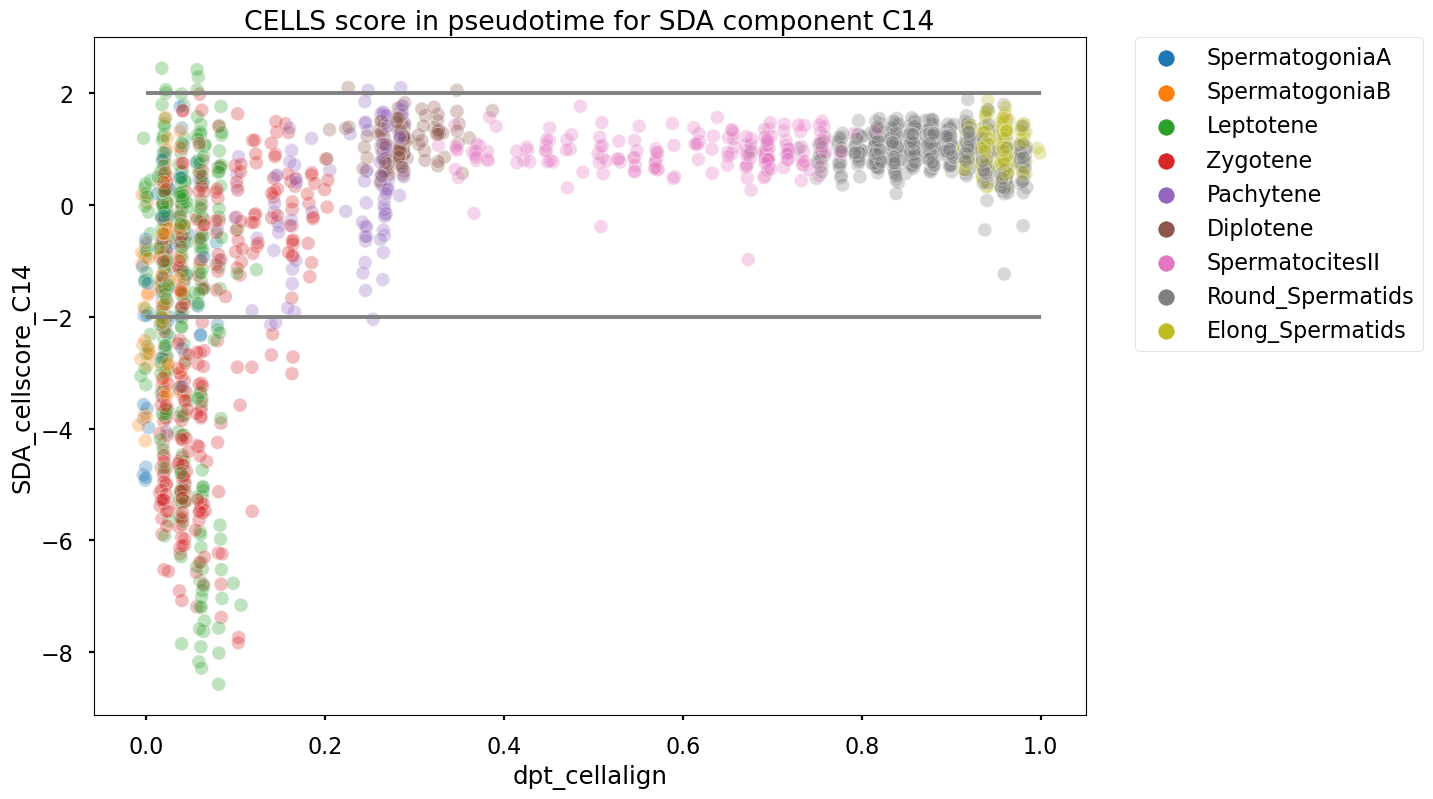

In [38]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.3, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C14')

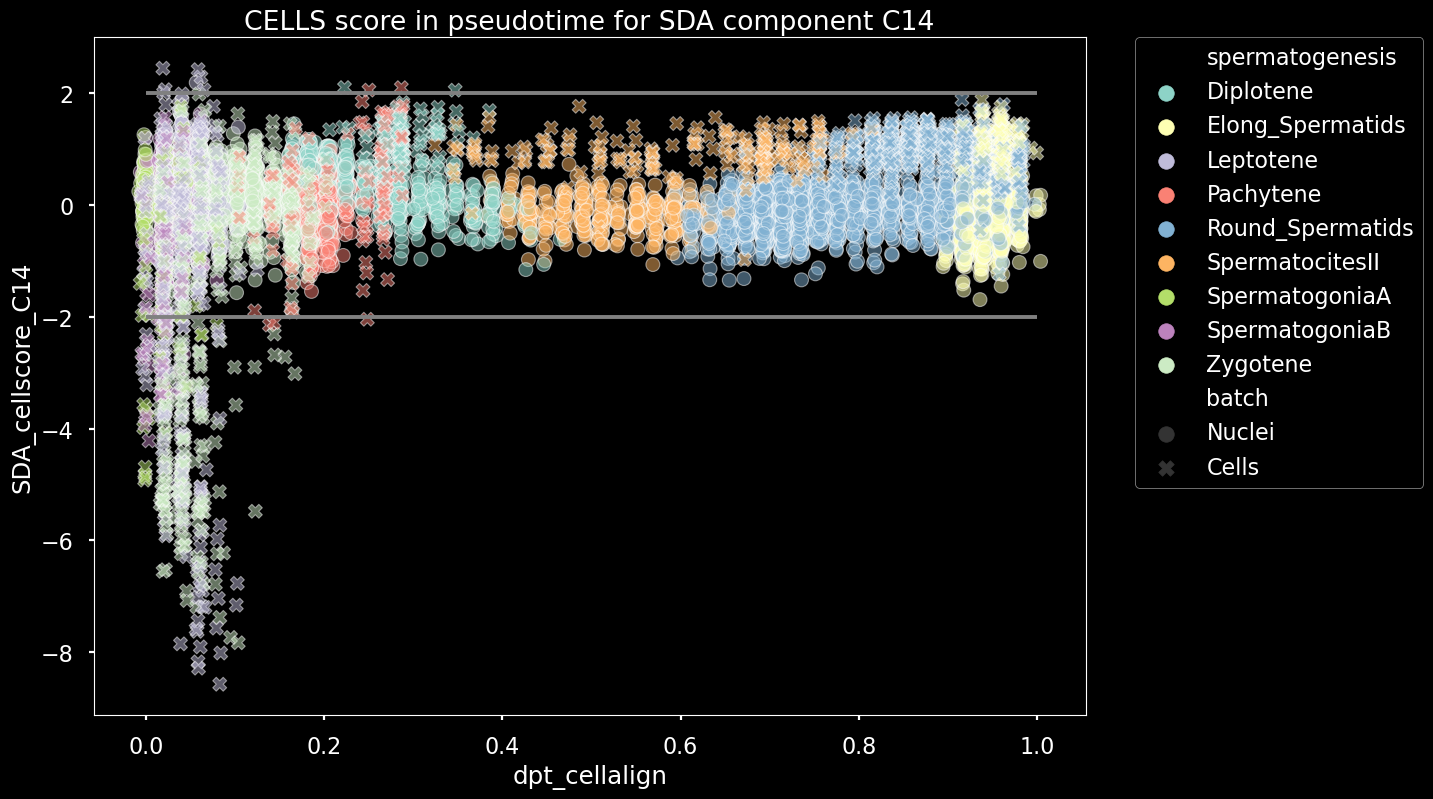

In [39]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.5, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C14')

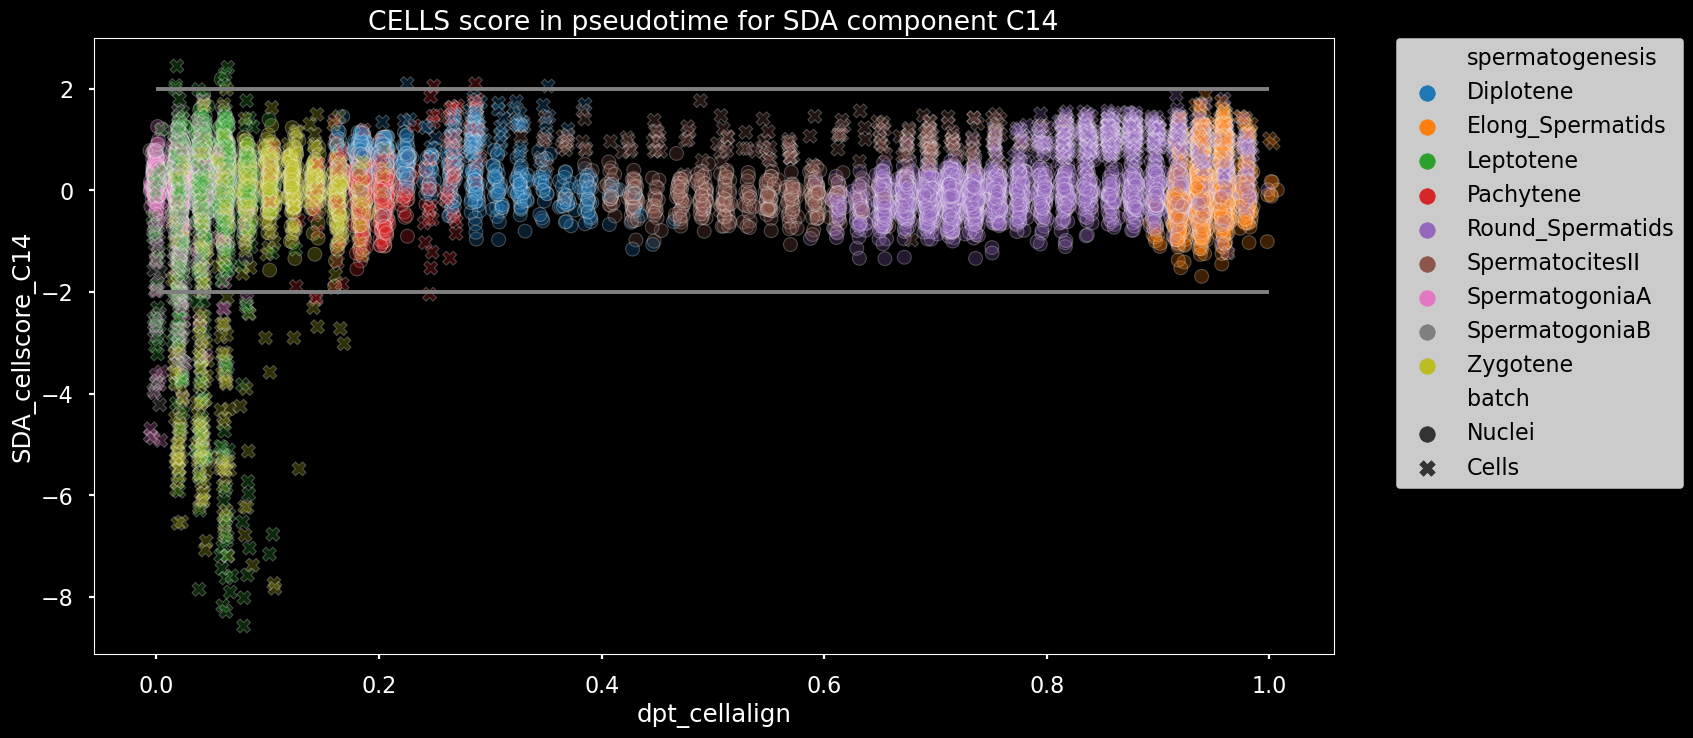

In [40]:
plt.rcParams['figure.figsize']=(16,8)
fig, ax = plt.subplots(1)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.25, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

## Gene set enrichment analysis

In [41]:
import gseapy as gp

In [42]:
!mkdir -p ./enrichment

In [43]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [44]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [45]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
258,GO_Cellular_Component_2023,Acrosomal Vesicle (GO:0001669),16/64,2.363926e-08,5.815257e-06,0,0,6.969231,122.382181,SPINK2;SPAG6;CCDC136;DKKL1;VPS13B;IQCF1;PCSK4;...
259,GO_Cellular_Component_2023,Motile Cilium (GO:0031514),15/73,1.008369e-06,1.240293e-04,0,0,5.398388,74.536490,ROPN1B;RSPH9;DNALI1;AK8;ENKUR;IFT74;TSGA10;RSP...
504,Human_Gene_Atlas,TestisIntersitial,124/568,1.099826e-49,8.028730e-48,0,0,6.487497,731.345435,ROPN1B;AQP5;SPATA20;ZDHHC3;CCT6B;TEKT2;ROPN1L;...
505,Human_Gene_Atlas,Testis,68/384,6.680631e-22,2.438430e-20,0,0,4.704582,229.384424,ROPN1B;DYRK3;CETN1;RPL10L;YBX2;MEA1;PCSK4;BOLL...
506,Human_Gene_Atlas,TestisGermCell,50/314,1.691113e-14,4.115041e-13,0,0,4.066781,128.960892,CRISP2;AQP5;SLCO6A1;DNALI1;HMGB4;CCT6B;ZCWPW1;...


In [46]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [47]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None)

In [48]:
table_pos = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [49]:
table_pos['Component'] = f'{comp}P'

In [50]:
table_pos['Batch diff'] = batch_effect_pos

In [51]:
table_pos['N cells'] = POSITIVE

In [52]:
table_pos

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
258,GO_Cellular_Component_2023,Acrosomal Vesicle (GO:0001669),16/64,5.815257e-06,6.969231,122.382181,SPINK2;SPAG6;CCDC136;DKKL1;VPS13B;IQCF1;PCSK4;...,14P,Yes,17
259,GO_Cellular_Component_2023,Motile Cilium (GO:0031514),15/73,1.240293e-04,5.398388,74.536490,ROPN1B;RSPH9;DNALI1;AK8;ENKUR;IFT74;TSGA10;RSP...,14P,Yes,17
504,Human_Gene_Atlas,TestisIntersitial,124/568,8.028730e-48,6.487497,731.345435,ROPN1B;AQP5;SPATA20;ZDHHC3;CCT6B;TEKT2;ROPN1L;...,14P,Yes,17
505,Human_Gene_Atlas,Testis,68/384,2.438430e-20,4.704582,229.384424,ROPN1B;DYRK3;CETN1;RPL10L;YBX2;MEA1;PCSK4;BOLL...,14P,Yes,17
506,Human_Gene_Atlas,TestisGermCell,50/314,4.115041e-13,4.066781,128.960892,CRISP2;AQP5;SLCO6A1;DNALI1;HMGB4;CCT6B;ZCWPW1;...,14P,Yes,17


In [53]:
table_pos.to_csv(f'enrichment/enrichr_C{comp}P.csv', header=False, index_label=False, index=None, sep='\t')

In [54]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [55]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [56]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Ribosome,79/158,2.743871e-42,7.518206e-40,0,0,11.135780,1065.685267,RPL4;RPL5;RPL30;RPL3;RPL32;RPL34;RPLP1;RPLP0;R...
1,KEGG_2021_Human,Parkinson disease,85/249,3.822506e-30,5.236834e-28,0,0,5.765807,390.556447,NDUFA13;NDUFA12;COX4I1;PARK7;COX6A1;COX7C;UBE2...
2,KEGG_2021_Human,Amyotrophic lateral sclerosis,104/364,3.283117e-29,2.998580e-27,0,0,4.478509,293.728293,NDUFA13;NUP107;NDUFA12;COX6A1;ACTB;ACTG1;PSMD8...
3,KEGG_2021_Human,Prion disease,86/273,1.236131e-27,8.467497e-26,0,0,5.112779,316.776599,RYR2;NDUFA13;NDUFA12;COX4I1;LAMC1;COX6A1;COX7C...
4,KEGG_2021_Human,Coronavirus disease,78/232,2.943437e-27,1.613004e-25,0,0,5.613533,342.931973,RPL4;RPL5;RPL30;RPL3;RPL32;RPL34;RPLP1;RPLP0;R...
...,...,...,...,...,...,...,...,...,...,...
320,GO_Cellular_Component_2023,Mitotic Spindle (GO:0072686),27/143,7.452166e-05,5.961733e-04,0,0,2.506950,23.827105,PHLPP2;CLTC;HNRNPU;KIF11;GOLGA2;CDC42;NGRN;TPR...
321,GO_Cellular_Component_2023,Respiratory Chain Complex IV (GO:0045277),8/19,9.139185e-05,7.159028e-04,0,0,7.790685,72.456133,COX4I1;UQCRFS1;COX5B;COX6A1;COX6C;COX5A;COX7C;...
650,Human_Gene_Atlas,721 B lymphoblasts,268/1543,4.493298e-31,3.414906e-29,0,0,2.472784,172.792082,EIF4A1;VARS;HNRNPU;HNRNPR;ENO1;EPRS;SMC3;GABPB...
651,Human_Gene_Atlas,CD34+,107/645,1.839542e-11,6.990259e-10,0,0,2.196519,54.295586,RPL3;NUP107;PDCD6;CSE1L;ZMYND8;HNRNPU;HNRNPR;N...


In [57]:
table_neg = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [58]:
table_neg['Component'] = f'{comp}N'

In [59]:
table_neg['Batch diff'] = batch_effect_neg

In [60]:
table_neg['N cells'] = NEGATIVE

In [61]:
table_neg

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
0,KEGG_2021_Human,Ribosome,79/158,7.518206e-40,11.135780,1065.685267,RPL4;RPL5;RPL30;RPL3;RPL32;RPL34;RPLP1;RPLP0;R...,14N,Yes,320
1,KEGG_2021_Human,Parkinson disease,85/249,5.236834e-28,5.765807,390.556447,NDUFA13;NDUFA12;COX4I1;PARK7;COX6A1;COX7C;UBE2...,14N,Yes,320
2,KEGG_2021_Human,Amyotrophic lateral sclerosis,104/364,2.998580e-27,4.478509,293.728293,NDUFA13;NUP107;NDUFA12;COX6A1;ACTB;ACTG1;PSMD8...,14N,Yes,320
3,KEGG_2021_Human,Prion disease,86/273,8.467497e-26,5.112779,316.776599,RYR2;NDUFA13;NDUFA12;COX4I1;LAMC1;COX6A1;COX7C...,14N,Yes,320
4,KEGG_2021_Human,Coronavirus disease,78/232,1.613004e-25,5.613533,342.931973,RPL4;RPL5;RPL30;RPL3;RPL32;RPL34;RPLP1;RPLP0;R...,14N,Yes,320
...,...,...,...,...,...,...,...,...,...,...
320,GO_Cellular_Component_2023,Mitotic Spindle (GO:0072686),27/143,5.961733e-04,2.506950,23.827105,PHLPP2;CLTC;HNRNPU;KIF11;GOLGA2;CDC42;NGRN;TPR...,14N,Yes,320
321,GO_Cellular_Component_2023,Respiratory Chain Complex IV (GO:0045277),8/19,7.159028e-04,7.790685,72.456133,COX4I1;UQCRFS1;COX5B;COX6A1;COX6C;COX5A;COX7C;...,14N,Yes,320
650,Human_Gene_Atlas,721 B lymphoblasts,268/1543,3.414906e-29,2.472784,172.792082,EIF4A1;VARS;HNRNPU;HNRNPR;ENO1;EPRS;SMC3;GABPB...,14N,Yes,320
651,Human_Gene_Atlas,CD34+,107/645,6.990259e-10,2.196519,54.295586,RPL3;NUP107;PDCD6;CSE1L;ZMYND8;HNRNPU;HNRNPR;N...,14N,Yes,320


In [62]:
table_neg.to_csv(f'enrichment/enrichr_C{comp}N.csv', header=False, index_label=False, index=None, sep='\t')

## Plot genes average expression for positive and negative module

In [63]:
!mkdir -p ./plots

In [64]:
adata.layers

Layers with keys: SCT_counts, correct_counts, raw_counts, scaled_counts, spliced, unspliced

In [65]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [66]:
adata.obs[f'module_pos_C{comp}'] = np.array( np.mean(adata[:,genes].layers['scaled_counts'], 1) )

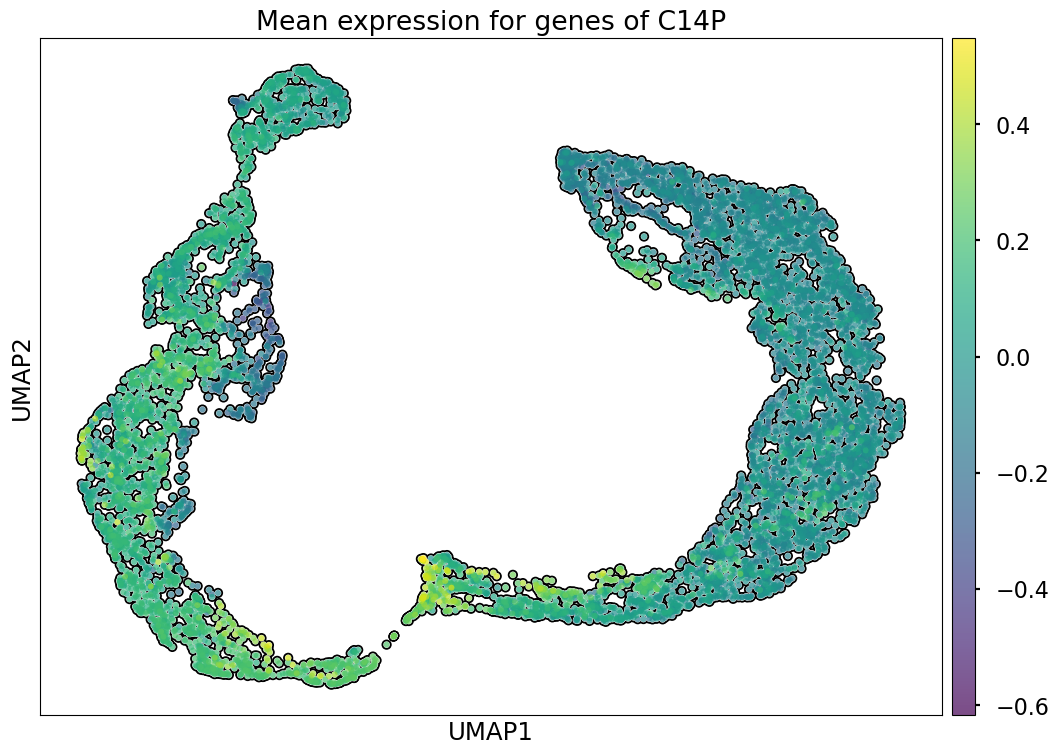

In [67]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}P_white.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

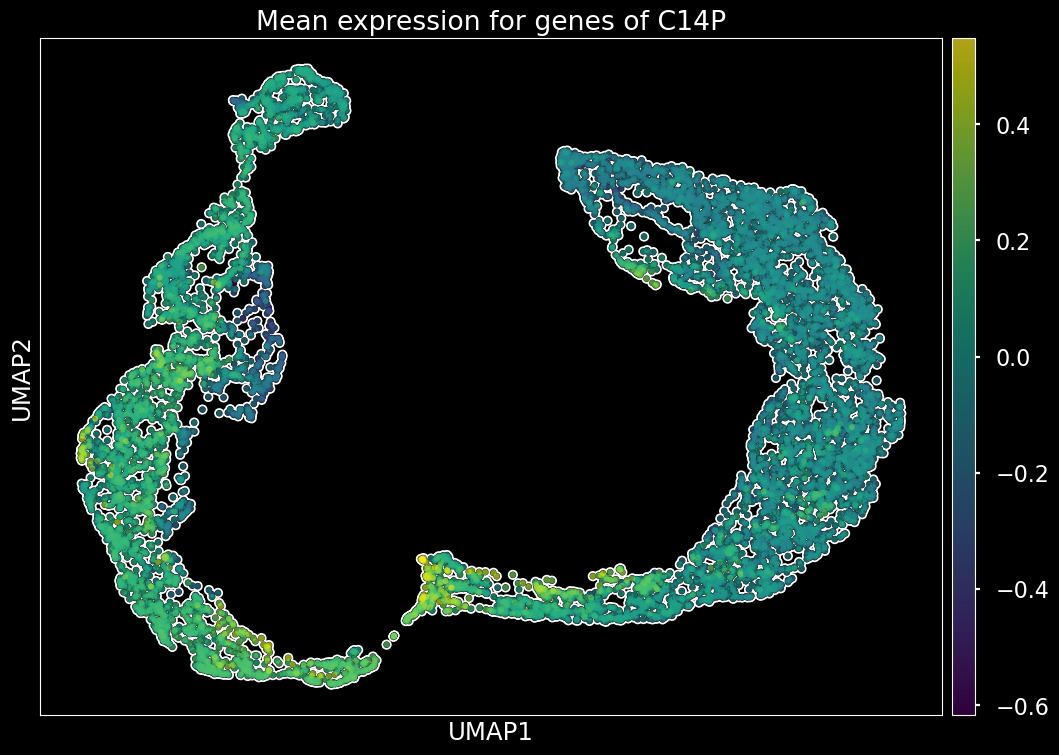

In [68]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}P_dark.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

In [69]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [70]:
adata.obs[f'module_neg_C{comp}'] = np.array( np.mean(adata[:,genes].layers['SCT_counts'], 1) )

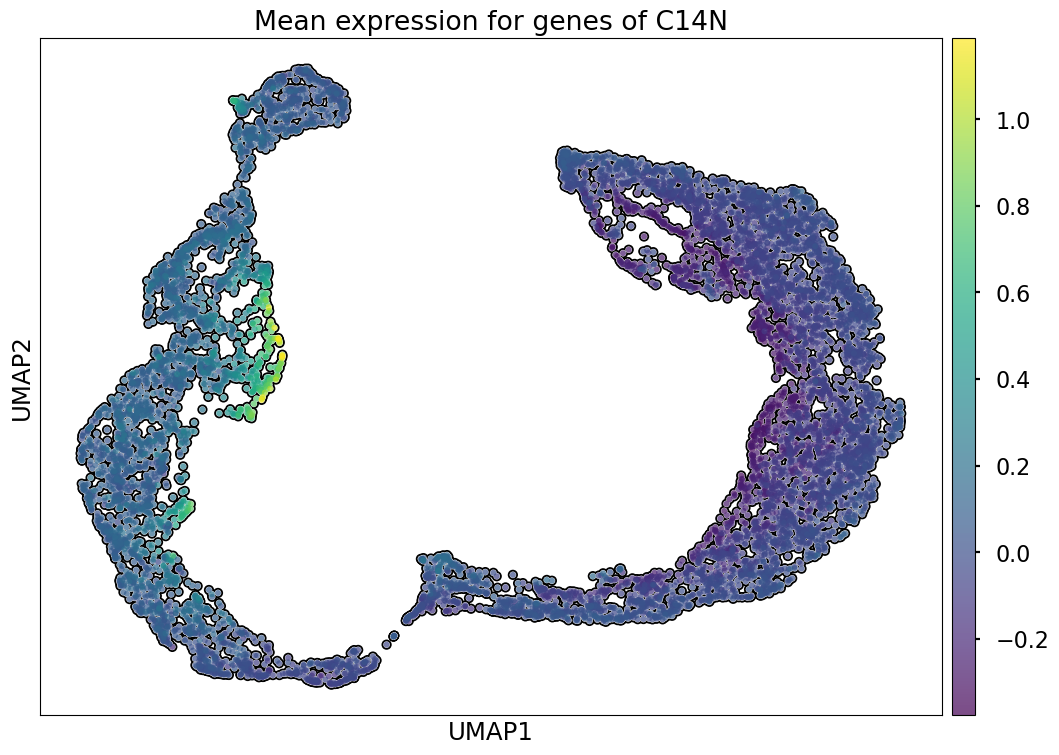

In [71]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}N_white.png',
           title=f'Mean expression for genes of C{comp}N', size=75)

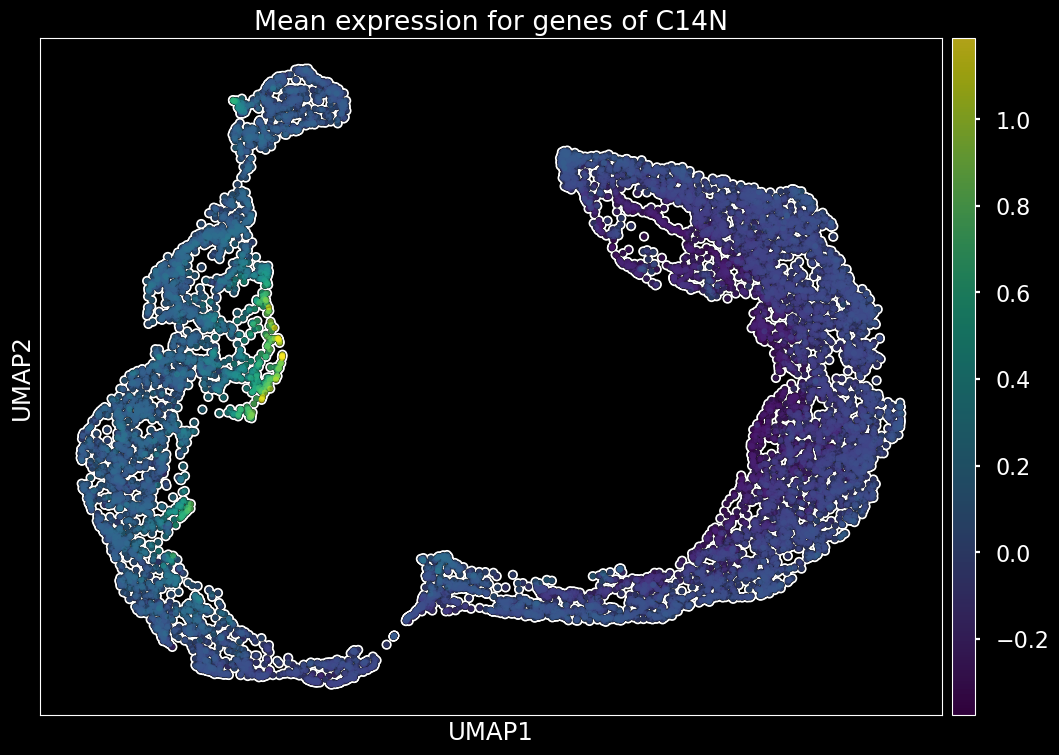

In [72]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}N_dark.png',
           title=f'Mean expression for genes of C{comp}N', size=75)